<a href="https://colab.research.google.com/github/khulaifi27/Tugas-semester-6/blob/main/Selamat_Datang_di_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selamat Datang di Colab!

In [1]:
!pip install scikit-image opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import active_contour
from skimage.color import rgb2gray
from skimage.filters import sobel
from skimage import img_as_float

Saving download (1).jpg to download (1).jpg


(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

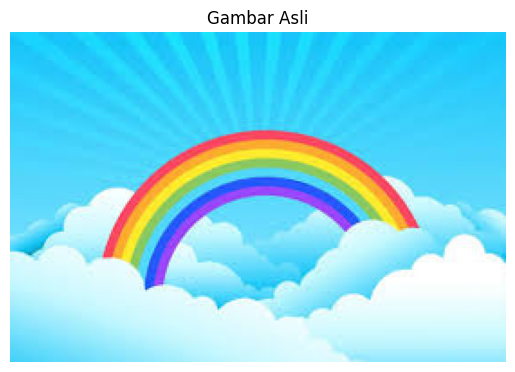

In [13]:
from google.colab import files
uploaded = files.upload()

# Ambil nama file
import os
filename = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

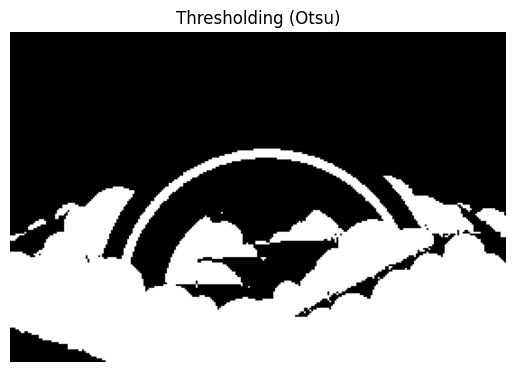

In [14]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Otsu Thresholding
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholding (Otsu)")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

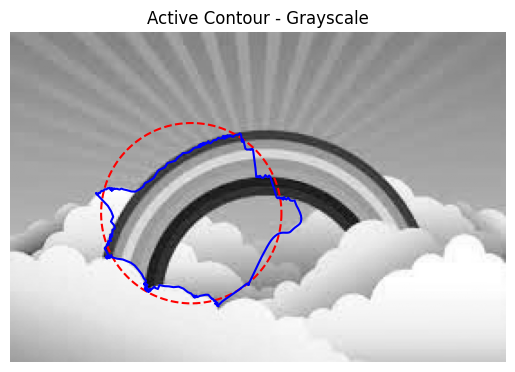

In [15]:
gray_float = img_as_float(rgb2gray(img_rgb))

# Inisialisasi lingkaran
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 50*np.sin(s)
c = 100 + 50*np.cos(s)
init = np.array([r, c]).T

snake = active_contour(gray_float, init)

plt.imshow(gray_float, cmap='gray')
plt.plot(init[:, 1], init[:, 0], '--r')
plt.plot(snake[:, 1], snake[:, 0], '-b')
plt.title("Active Contour - Grayscale")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

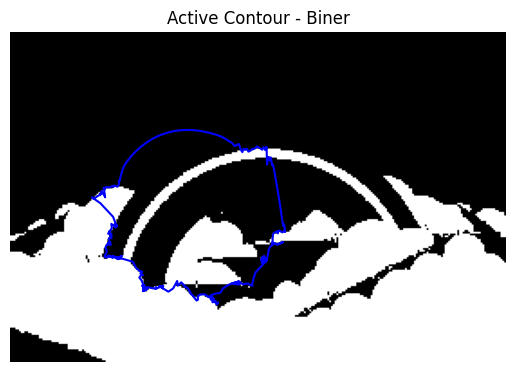

In [16]:
binary = thresh / 255.0

snake_bin = active_contour(binary, init)

plt.imshow(binary, cmap='gray')
plt.plot(snake_bin[:, 1], snake_bin[:, 0], '-b')
plt.title("Active Contour - Biner")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

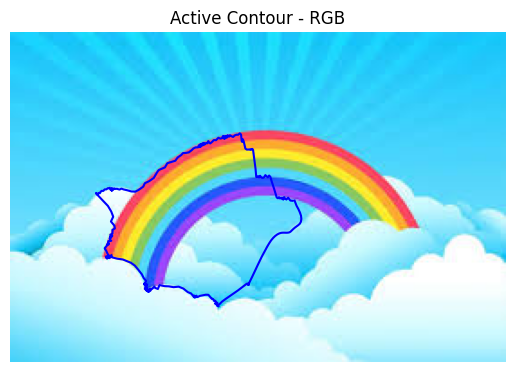

In [17]:
rgb_float = img_as_float(img_rgb)

# gunakan channel grayscale saja sebagai energi
snake_rgb = active_contour(rgb2gray(rgb_float), init)

plt.imshow(img_rgb)
plt.plot(snake_rgb[:, 1], snake_rgb[:, 0], '-b')
plt.title("Active Contour - RGB")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

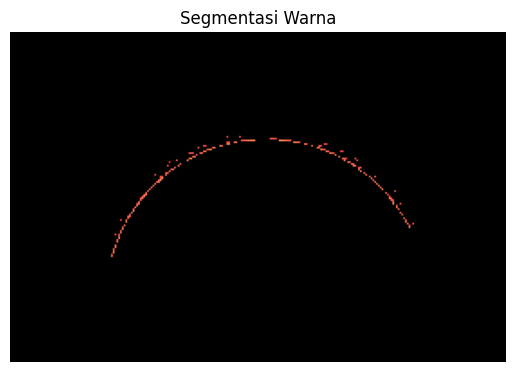

In [18]:
# Konversi ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Contoh segmentasi warna merah
lower = np.array([0, 120, 70])
upper = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.imshow(result)
plt.title("Segmentasi Warna")
plt.axis('off')

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

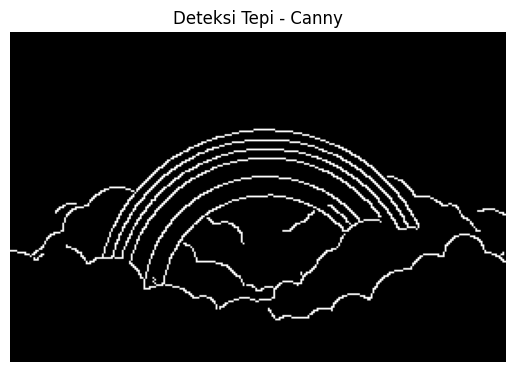

In [19]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Deteksi Tepi - Canny")
plt.axis('off')

<div class="markdown-google-sans">

## Ilmu data
</div>

Dengan Colab, Anda dapat memanfaatkan kecanggihan library Python yang populer untuk menganalisis dan memvisualisasikan data. Sel kode di bawah menggunakan <strong>numpy</strong> untuk menghasilkan beberapa data acak, dan menggunakan <strong>matplotlib</strong> untuk memvisualisasikannya. Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Anda dapat mengimpor data sendiri ke notebook Colab dari akun Google Drive Anda, termasuk dari spreadsheet, GitHub, dan berbagai sumber lainnya. Untuk mempelajari lebih lanjut pengimporan data dan bagaimana Colab dapat digunakan untuk ilmu data, lihat link di bawah pada bagian <a href="#working-with-data">Bekerja dengan Data</a>.

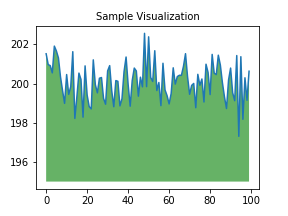

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Notebook Colab mengeksekusi kode di server cloud Google. Artinya, Anda dapat memanfaatkan kecanggihan hardware Google, termasuk <a href="#using-accelerated-hardware">GPU dan TPU</a>, terlepas dari kecanggihan komputer Anda. Yang Anda butuhkan hanyalah browser.

Misalnya, jika Anda harus menunggu kode <strong>pandas</strong> selesai dijalankan dan ingin mempercepat prosesnya, Anda dapat beralih ke Runtime GPU dan menggunakan library seperti <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> yang menyediakan akselerasi tanpa perubahan kode.

Untuk mempelajari lebih lanjut cara mempercepat pandas di Colab, lihat <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">panduan 10 menit</a> atau
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demo analisis data pasar saham AS</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Dengan Colab, Anda dapat mengimpor set data gambar, melatih pengklasifikasi gambar di dalamnya, dan mengevaluasi model hanya dengan <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">beberapa baris kode</a>.

Colab digunakan secara luas di komunitas machine learning dengan berbagai penerapan meliputi:
- Memulai TensorFlow
- Mengembangkan dan melatih jaringan neural
- Bereksperimen dengan TPU
- Menyebarkan riset AI
- Membuat tutorial

Untuk melihat sampel notebook Colab yang menunjukkan penerapan machine learning, lihat <a href="#machine-learning-examples">contoh machine learning</a> di bawah.

<div class="markdown-google-sans">

## Referensi Lainnya

### Bekerja dengan Notebook di Colab

</div>

- [Ringkasan Colab](/notebooks/basic_features_overview.ipynb)
- [Panduan tentang Markdown](/notebooks/markdown_guide.ipynb)
- [Mengimpor library dan menginstal dependensi](/notebooks/snippets/importing_libraries.ipynb)
- [Menyimpan dan memuat notebook di GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulir interaktif](/notebooks/forms.ipynb)
- [Widget interaktif](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Bekerja dengan Data
</div>

- [Memuat data: Drive, Spreadsheet, dan Google Cloud Storage](/notebooks/io.ipynb)
- [Diagram: memvisualisasikan data](/notebooks/charts.ipynb)
- [Memulai BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

Berikut beberapa notebook yang terkait dengan Machine Learning, termasuk kursus Machine Learning online Google. Buka <a href="https://developers.google.com/machine-learning/crash-course/">situs kursus lengkap</a> untuk mengetahui info selengkapnya.
- [Pengantar Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pengantar RAPIDS cuDF untuk mempercepat pandas](https://nvda.ws/rapids-cudf)
- [Mulai menggunakan mode akselerator cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Menggunakan Hardware yang Diakselerasi
</div>

- [Melatih CNN untuk mengklasifikasikan angka dari tulisan tangan pada set data MNIST menggunakan Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Melatih Vision Transformer &#40;ViT&#41; untuk klasifikasi gambar dengan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Klasifikasi teks dengan model bahasa transformer menggunakan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Contoh bagus

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Melatih model bahasa miniGPT dengan Stack AI JAX</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Fine-tuning LoRA/QLoRA untuk LLM menggunakan Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning &#40;PEFT&#41; Gemma dengan LoRA dan QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Memuat Checkpoint Hugging Face Transformer</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Kuantisasi Bilangan Bulat 8-bit di Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Pelatihan dan inferensi Float8 dengan model Transformer sederhana</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Melakukan pra-pelatihan Transformer dari awal dengan KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST sederhana</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Klasifikasi gambar dari awal menggunakan Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Klasifikasi Gambar dengan KerasHub</a>
